# **C03 - Simulación del precio del activo y valuación de una call**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 24 de agosto de 2026

---

En este notebook se simula el precio de una acción al vencimiento mediante movimiento browniano geométrico, se construye a partir de esa muestra el pago descontado de una opción call fuera del dinero y se contrasta el precio obtenido contra la fórmula de Black-Scholes, con el propósito de comprobar que la valuación por simulación y la analítica describen el mismo objeto.

## Índice de contenidos

1. Sección 1 — Parámetros y una trayectoria
2. Sección 2 — Simulación de la distribución al vencimiento
3. Sección 3 — Pago descontado de la call
4. Sección 4 — Comparación con Black-Scholes
5. Sección 5 — Conclusiones

## Importación de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import time

## 1. Parámetros y una trayectoria

**Ejercicio:** calcular el precio de la acción en el tiempo $t$ con los valores dados en clase.

El precio al vencimiento se obtiene con la solución del movimiento browniano geométrico bajo la medida neutral al riesgo, donde una sola variable normal estándar resume toda la incertidumbre del horizonte.

$$S_T = S_0\exp\left[\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}Z\right], \qquad Z \sim N(0,1)$$

El strike de 110 pesos coloca a la opción fuera del dinero desde el inicio, detalle que conviene tener presente porque condiciona todo lo que sigue.

In [2]:
S_0 = 100
K = 110
T = 1
r = 0.05
sigma = 0.2
M = 10000

In [3]:
np.random.seed(42)

S_t = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * np.random.normal(0, 1))

print(f"Un precio simulado al vencimiento: {S_t:.4f}")

Un precio simulado al vencimiento: 113.8080


El valor obtenido de 113.8080 pesos corresponde a un solo recorrido y por sí mismo no dice nada sobre el precio de la opción, aunque ilustra bien el mecanismo, ya que basta una extracción normal para trasladar el precio inicial de 100 pesos hasta el vencimiento, y el hecho de que este resultado particular termine por encima del strike de 110 no autoriza a concluir que la call vaya a ejercerse, pues otro sorteo habría producido un desenlace distinto.

## 2. Simulación de la distribución al vencimiento

Una sola trayectoria no describe el comportamiento del activo, por ello el experimento se repite 10,000 veces con la misma semilla y se conserva el precio final de cada recorrido.

El cálculo admite dos formas equivalentes, ya que puede resolverse con un ciclo que extrae una normal por iteración o bien pidiendo las 10,000 normales de una sola vez para evaluar la fórmula sobre el arreglo completo, y conviene comprobar de manera explícita que ambas rutas producen exactamente los mismos números antes de quedarse con la segunda.

In [4]:
np.random.seed(42)
inicio = time.time()

resultados_ciclo = []
for simulacion in range(M):
    S_t = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * np.random.normal(0, 1))
    resultados_ciclo.append(S_t)

resultados_ciclo = np.array(resultados_ciclo)
tiempo_ciclo = time.time() - inicio

np.random.seed(42)
inicio = time.time()

Z = np.random.normal(0, 1, M)
resultados = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

tiempo_vectorizado = time.time() - inicio

print(f"Tiempo con ciclo explícito: {tiempo_ciclo * 1000:.2f} ms")
print(f"Tiempo con evaluación vectorizada: {tiempo_vectorizado * 1000:.2f} ms")
print(f"Factor de mejora: {tiempo_ciclo / tiempo_vectorizado:.0f} veces")
print(f"Máxima diferencia entre ambos resultados: {np.max(np.abs(resultados_ciclo - resultados)):.2e}")

Tiempo con ciclo explícito: 24.15 ms
Tiempo con evaluación vectorizada: 0.96 ms
Factor de mejora: 25 veces
Máxima diferencia entre ambos resultados: 0.00e+00


TBD_vectorizacion

In [5]:
print(f"Primeros cinco precios simulados: {np.round(resultados[:5], 4)}")
print(f"Precio promedio simulado: {resultados.mean():.4f}")
print(f"Precio esperado teórico S0*e^(rT): {S_0 * np.exp(r * T):.4f}")
print(f"Precio mínimo simulado: {resultados.min():.4f}")
print(f"Precio máximo simulado: {resultados.max():.4f}")
print(f"Proporción de escenarios por encima de K: {(resultados > K).mean():.4f}")

Primeros cinco precios simulados: [113.808  100.235  117.2968 139.739   98.331 ]
Precio promedio simulado: 105.0970
Precio esperado teórico S0*e^(rT): 105.1271
Precio mínimo simulado: 47.0255
Precio máximo simulado: 225.9735
Proporción de escenarios por encima de K: 0.3708


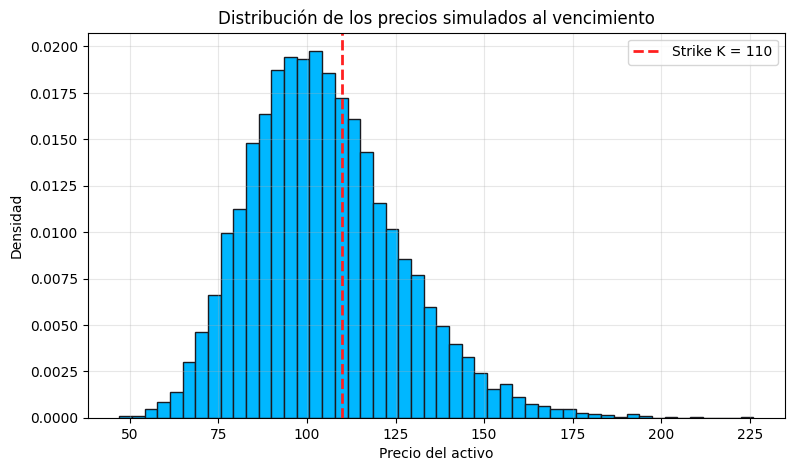

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(resultados, bins=50, density=True, color="#00B7FF", edgecolor="#1A1B21")
plt.axvline(K, color="#FF2020", linestyle="--", linewidth=2, label=f"Strike K = {K}")

plt.title("Distribución de los precios simulados al vencimiento")
plt.xlabel("Precio del activo")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El promedio de los 10,000 precios simulados es 105.0970 pesos frente a los 105.1271 que predice $S_0e^{rT}$, con una diferencia de 0.0301 atribuible al muestreo, mientras el rango va de 47.0255 a 225.9735 y deja ver la asimetría de la lognormal, ya que la caída máxima observada representa una pérdida de 53% y el alza máxima una ganancia de 126%, es decir, el proceso admite desviaciones al alza mucho mayores que a la baja porque el precio nunca puede volverse negativo.

Sólo 37.08% de los escenarios superan el strike de 110 pesos, cifra que anticipa el resultado de la valuación, pues casi dos terceras partes de las trayectorias dejarán a la opción sin valor al vencimiento.

## 3. Pago descontado de la call

**Ejercicio:** separar los valores mayores a $K$ y obtener la esperanza correspondiente.

El pago de la call es la diferencia entre el precio final y el strike cuando esa diferencia es positiva, y cero en cualquier otro caso, de modo que la separación pedida equivale a construir el vector de pagos y conservar los ceros para no distorsionar el promedio, operación que resuelve `np.maximum` sobre el arreglo completo sin necesidad de recorrerlo elemento por elemento.

$$C = e^{-rT}E[\max(S_T - K, 0)]$$

In [7]:
pagos = np.maximum(resultados - K, 0)
precio_montecarlo = np.mean(pagos * np.exp(-r * T))

print(f"Escenarios con pago positivo: {(pagos > 0).sum()} de {M}")
print(f"Pago promedio sobre todos los escenarios: {pagos.mean():.4f}")
print(f"Pago promedio sólo entre los ganadores: {pagos[pagos > 0].mean():.4f}")
print(f"Precio Monte Carlo de la call: {precio_montecarlo:.4f}")

Escenarios con pago positivo: 3708 de 10000
Pago promedio sobre todos los escenarios: 6.3546
Pago promedio sólo entre los ganadores: 17.1377
Precio Monte Carlo de la call: 6.0447


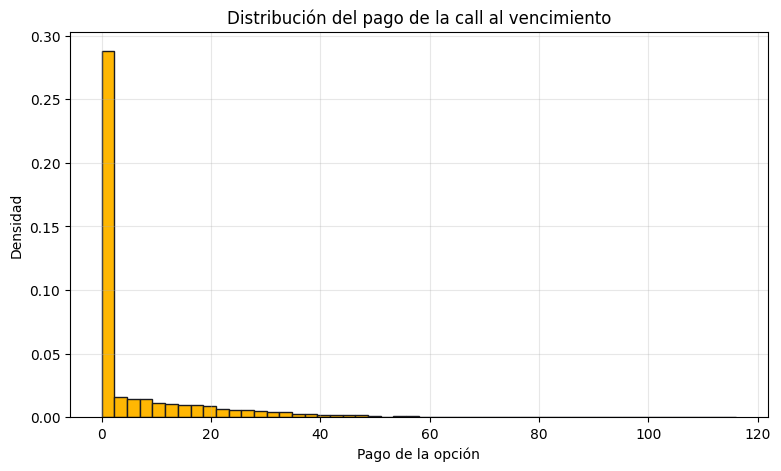

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(pagos, bins=50, density=True, color="#FFB703", edgecolor="#1A1B21")

plt.title("Distribución del pago de la call al vencimiento")
plt.xlabel("Pago de la opción")
plt.ylabel("Densidad")
plt.grid(alpha=0.3)
plt.show()

De los 10,000 escenarios, 3,708 generan un pago positivo y el resto aporta ceros que sí deben conservarse en el promedio, ya que el precio de la opción es la esperanza sobre todos los desenlaces posibles y no sólo sobre los favorables, distinción que las cifras vuelven evidente, pues el pago promedio entre los ganadores asciende a 17.1377 pesos mientras el promedio sobre la muestra completa cae a 6.3546.

Ese contraste explica la forma del histograma, donde la barra de cero concentra la mayor parte de la masa y el resto se reparte en una cola decreciente, y al descontar el promedio general a la tasa libre de riesgo se obtiene un precio de 6.0447 pesos para la call.

## 4. Comparación con Black-Scholes

**Ejercicio:** usar la fórmula de Black-Scholes para determinar el precio justo de la opción y compararlo con el obtenido por la vía clásica.

$$C_{BS} = S_0N(d_1) - Ke^{-rT}N(d_2), \qquad d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

In [9]:
d_1 = (np.log(S_0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
d_2 = d_1 - sigma * np.sqrt(T)
C = S_0 * norm.cdf(d_1) - K * np.exp(-r * T) * norm.cdf(d_2)

print(f"d1: {d_1:.6f}")
print(f"d2: {d_2:.6f}")
print(f"N(d2), probabilidad teórica de ejercicio: {norm.cdf(d_2):.6f}")
print()
print(f"Precio Black-Scholes: {C:.4f}")
print(f"Precio Monte Carlo:   {precio_montecarlo:.4f}")
print(f"Diferencia absoluta:  {abs(C - precio_montecarlo):.4f}")
print(f"Diferencia relativa:  {100 * abs(C - precio_montecarlo) / C:.4f}%")

d1: -0.126551
d2: -0.326551
N(d2), probabilidad teórica de ejercicio: 0.372004

Precio Black-Scholes: 6.0401
Precio Monte Carlo:   6.0447
Diferencia absoluta:  0.0046
Diferencia relativa:  0.0768%


La fórmula analítica entrega 6.0401 pesos contra los 6.0447 de la simulación, con una diferencia de 0.0046 equivalente a 0.0768% del valor teórico, coincidencia notablemente estrecha para 10,000 trayectorias que conviene atribuir a la semilla elegida y no a una precisión general del método.

Los valores intermedios agregan una lectura útil, ya que $d_2 = -0.326551$ implica $N(d_2) = 0.372004$, es decir, la probabilidad teórica de que la opción termine dentro del dinero bajo la medida neutral al riesgo, y la simulación arrojó 0.3708 de escenarios por encima del strike, de modo que ambos enfoques coinciden también en la frecuencia y no solamente en el precio.

## 5. Conclusiones

La valuación por simulación y la fórmula de Black-Scholes describen el mismo objeto, y la evidencia es doble, pues los precios difieren en 0.0046 pesos equivalentes a 0.0768%, y además la proporción simulada de escenarios dentro del dinero, 0.3708, reproduce el valor de $N(d_2) = 0.372004$ que la propia fórmula utiliza como probabilidad de ejercicio.

El resultado más instructivo del ejercicio es la distancia entre 17.1377 y 6.3546, ya que el primer número es lo que paga la opción cuando paga y el segundo es lo que vale en promedio antes de saber si pagará, de modo que conservar los ceros no es un detalle de programación sino la definición misma de la esperanza que se está calculando.

Conviene reconocer que la cercanía obtenida no debe generalizarse, ya que corresponde a una realización con semilla fija y otra habría producido una discrepancia mayor con el mismo número de trayectorias, por ello la manera correcta de reportar un precio Monte Carlo incluye alguna medida de su error y no sólo el valor puntual.

La continuación natural consiste en repetir el ejercicio con la opción put para verificar la paridad, además de acompañar el precio simulado con un intervalo de confianza construido a partir de la desviación estándar de los pagos descontados.